# M2 Statistics project 2023
# Date : 07/11/2023
# Author : Marco Iampieri

#### Premise 
In the first coding block below it is possible to find the python packages and the graphical setups which are gonna be utilized for this work

In [7]:
import numpy as np
from mpmath import mp
import scipy as sp
from scipy.optimize import curve_fit
from scipy.stats import chi2
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import sys
from IPython.utils import io
import warnings
warnings.simplefilter('ignore')

import matplotlib as mpl
mpl.rcParams['legend.frameon']  = False
mpl.rcParams['legend.fontsize'] = 'large'
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.titlesize']  = 18
mpl.rcParams['axes.labelsize']  = 18
mpl.rcParams['lines.linewidth'] = 2.5
mpl.rcParams['figure.figsize']  = (10, 7)

## I - Digit density of some irrational numbers.
The transcendental number π is suspected to be a normal number, i.e. a number that has an equal
frequency for each of its digits (and beyond, an equal density of any sequence of n digits, for all n).
Let’s try to verify this property over a (necessarily) small sample of digits.
### Section 1 : Function defining
In order to complete the required tasks, in the following coding block a few essential functions, which will provide the basic data to compute the statistically relevant parameters, are gonna be defined

In [6]:
#Generating the sequence of digits for a number present in the mpmath library (such as π)
def generate_number_digits(n,number):
    mp.dps = n 
    number_str = str(number)
    number_digits = [int(digit) for digit in number_str if digit.isdigit()]
    return number_digits[:n]

#Generating the sequence of digits for the concatenation of Fibonacci numbers
def fib_digits(n):
    fib = '11'
    fibi,fibj = 1,1
    while len(fib) < n:
        fibk = fibi + fibj
        fibi, fibj = fibj, fibk
        fib += str(fibk)
    fib = fib[0:n]
    fib_digits = [int(digit) for digit in fib if digit.isdigit()]
    return fib_digits

#Generating the sequence of digits for the Lucas sequence
def luc_digits(n):
    luc = '21'
    luci,lucj = 2,1
    while len(luc) < n:
        luck = luci + lucj
        luci, lucj = lucj, luck
        luc += str(luck)
    luc = luc[0:n]
    luc_digits = [int(digit) for digit in luc if digit.isdigit()]
    return luc_digits

#Generating the sequence of digits for the Padovan sequence
def pad_digits(n):
    pad = '111'
    padi,padj,padk = 1,1,1
    while len(pad) < n:
        padl = padi + padj
        padi, padj, padk = padj, padk, padl
        pad += str(padl)
    pad = pad[0:n]
    pad_digits = [int(digit) for digit in pad if digit.isdigit()]
    return pad_digits

#Generating randomly distributed variables
def Var_Z1(n):
    Z1 = ''
    while len(Z1)<50000:
        X = np.random.uniform(1,1.5,size=n)
        Zi = np.prod(X)
        Z1 += str(Zi)[0]
    Z1_digits = [int(digit) for digit in Z1 if digit.isdigit()]
    return Z1_digits

def Var_Z2(n):
    Z2 = ''
    while len(Z2)<50000:
        X = np.random.uniform(1.5,2)
        Y = np.random.uniform(1,1.5)
        Zi = (X/Y)**n
        Z2 += str(Zi)[0]
    Z2_digits = [int(digit) for digit in Z2 if digit.isdigit()]
    return Z2_digits

#Computing the frequency of each digit for a given number
def calculate_digit_frequencies(number_digits,digits):
    digit_frequencies = [0] * len(digits)
    for digit in number_digits:
        digit_frequencies[digit-(10-len(digits))] += 1/len(number_digits)       
    return digit_frequencies

#Computing the error associated to each frequency
def calculate_stds(digit_frequencies,n):
    stds = []
    for frequency in digit_frequencies :
        std = np.sqrt(((frequency)*(1-frequency))/n)
        stds.append(std)
    return stds

The following functions will take as inputs the results of those seen above, and utilize them to compute the results we are interested in (e.g. $\chi^2$ and fit parameters) and produce their graphical representation (such as the histograms and error ellipses)

In [33]:
#Printing the frequencies and the associated errors
def print_freq_and_err(digit_frequencies,digits,std) :
    for i in digits :
        print('{} frequency is {} ± {}'
              .format(int(i),digit_frequencies[int(i)-(10-len(digits))],std[int(i)-(10-len(digits))]))

#Drawing the histogram of frequencies for the input number
def plot_histogram(number_name,digits,digit_frequencies, std):
    '''
    This function plots the histogram of frequencies for the input number.

    Inputs:
        · number_name: string which will provide the graph title.
        · digits: array containing the digits that will be represented on the x-axis.
        · digit_frequencies: a list containing the frequency of each digit.
        · std : a list containing the error associated to each frequency.
    '''
    plt.bar(digits, digit_frequencies, yerr=std, capsize=5, color='skyblue')
    plt.xticks(digits)
    plt.xlabel('Digit')
    plt.ylabel('Frequency')
    plt.ylim([0, max(digit_frequencies)*1.15])
    plt.title('Digit Frequencies in {}'.format(number_name))
    plt.show()

#Defining the linear function that's gonna be utilized for the fit
def fit_func_lin(digit,alpha,beta) : 
    return alpha/10 + beta*digit

#Computing the correlation between the parameters obtained from the fit
def compute_correlation(errs) :
    par1_std = np.sqrt(errs[0,0])
    par2_std = np.sqrt(errs[1,1])
    corr = errs[0,1]/(par1_std*par2_std)
    return corr

#Printing the parameters and their correlation
def print_params_and_corr(params,errs) :
    print('\nAlpha value from fit = {} ± {}\nBeta value from fit = {} ± {}\nCorrelation = {}'
    .format(params[0],np.sqrt(errs[0,0]),params[1],np.sqrt(errs[1,1]),compute_correlation(errs)))

#Drawing the fit line on the histogram, along with the values of the parameters
def draw_fit(digits,params,fit_func) :
    plt.plot(digits, fit_func(digits, *params), 'b--',
        label='Fit results: α=%9f, β=%9f' % tuple(params))
    plt.legend(loc = 'upper right')

#Drawing the hypothesis line on the histogram, along with the ideal values of the parameters
def draw_hyp(digits,params,fit_func) :
    plt.plot(digits, fit_func(digits, *params),color='red',
        label='Hypothesis: α=%9f, β=%9f' % tuple(params))
    plt.legend(loc = 'upper right')

#Computing the chi-square corresponding to a certain set of parameters
def compute_chi_2(digits,digit_frequencies,stds,params,fit_func) :
    chi_2 = 0
    for digit in digits :
        index = int(digit)-(10-len(digits))
        chi_2 += ((digit_frequencies[index]-fit_func(digit,*params))/stds[index])**2
    return chi_2

#Printing the chi-square and the corresponding p-value
def print_chi_2_and_p_value(chi_2,digits,params) :
    n_dof = (len(digits)-len(params))                                                             #The p-value is obtained through the survival function  
    p_value = chi2.sf(chi_2,n_dof)                                                                #of the chi-square and the number of d.o.f.
    print('\nChi_2 value (with α = {}, β = {}) = {}\nChi_2/ndof = {}\nCorresponding p-value = {}'
          .format(params[0],params[1],chi_2,chi_2/n_dof,p_value))

#Drawing the covariance error elipse, centered in the coordinates where delta_chi-square=0
def err_ellipse(errs,center,cl):
    '''
    This function plots an ellipse from a covariance matrix for the case of 2 dof.

    Inputs:
        · errs: array with the covariance matrix.
        · center: array with the coordinates of the center of the ellipse.
        · cl: confidence level of the ellipse (between 0 and 1).
    '''
    
    x_std = np.sqrt(errs[0,0])
    y_std = np.sqrt(errs[1,1])
    correlation = errs[0,1]/(x_std*y_std)

    eig_val, eig_vec = np.linalg.eig(errs)
    lenght_axis = 2*np.sqrt(eig_val)
    angles_rad = 0.5*np.arctan((2*correlation*np.sqrt(errs[0,0])*np.sqrt(errs[1,1]))/((errs[0,0])-(errs[1,1])))
    angles = angles_rad*180/np.pi                                            # Transform the angles from radians to degrees

    cl_correction = chi2.ppf(cl,df=2)

    plt.figure()
    plt.scatter(1,0,color='red',label='Hypothesis',marker='x')              # Hypothesis
    plt.scatter(center[0],center[1],color='blue',label='Best fit',marker='o') # Ellipse center (Best fit)
    plt.legend()
    plt.xlabel('$\\alpha$')
    plt.ylabel('$\\beta$')
    plt.title('Covariance error ellipse')
    ax = plt.gca()
    ellipse = Ellipse((center[0],center[1]),
                      np.sqrt(cl_correction)*lenght_axis[0],
                      np.sqrt(cl_correction)*lenght_axis[1],
                      angle=angles,
                      color='blue',fill=False,label='Covariance error ellipse')
    ax.add_patch(ellipse)
    plt.show()

### Section 2 : Showing the results for π
In this section we'll see the results for each step indicated in the assignment

#### 1.1) Computing digit frequencies in π

In [760]:
N = 5 * 10**4
digits = np.linspace(0,9,10)
pi_digits = generate_number_digits(N,mp.pi)
frequencies = calculate_digit_frequencies(pi_digits,digits)
stds = calculate_stds(frequencies,N)
print_freq_and_err(frequencies,digits,stds)

0 frequency is 0.10066000000000948 ± 0.001345567273680566
1 frequency is 0.1010800000000096 ± 0.00134805662789074
2 frequency is 0.09734000000000846 ± 0.001325631354487414
3 frequency is 0.09896000000000896 ± 0.0013354169266562947
4 frequency is 0.10022000000000934 ± 0.0013429516119354968
5 frequency is 0.1010400000000096 ± 0.0013478198573994053
6 frequency is 0.10036000000000939 ± 0.0013437847327604784
7 frequency is 0.09954000000000914 ± 0.0013388934864283068
8 frequency is 0.10060000000000946 ± 0.0013452110615067626
9 frequency is 0.10020000000000934 ± 0.0013428325286498496


#### 1.2) Drawing the histogram

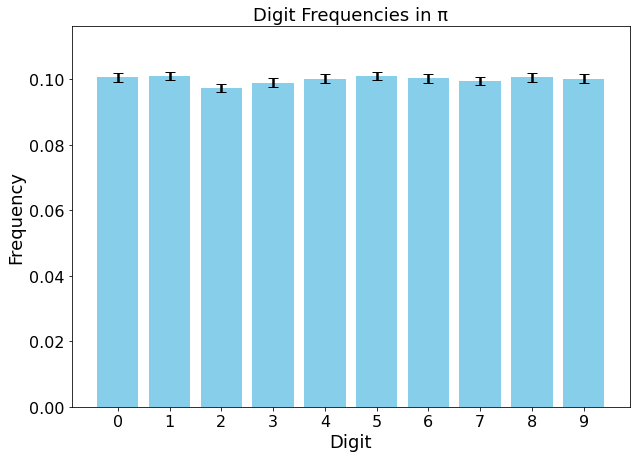

In [750]:
plot_histogram('π',digits,frequencies,stds)

#### 1.3) Fitting the histogram with a linear function

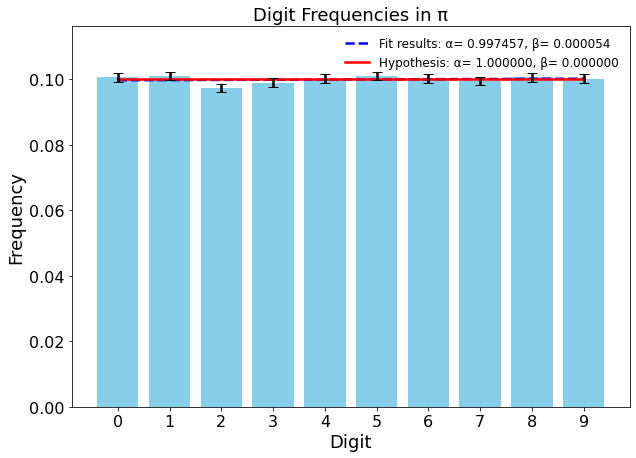

In [761]:
params,errs = curve_fit(fit_func_lin,digits,frequencies,absolute_sigma=True,sigma=stds)
draw_fit(digits,params,fit_func_lin)
draw_hyp(digits,[1,0],fit_func_lin)
plot_histogram('π',digits,frequencies, stds)

#### 1.4) Computing the parameters, the $\chi^2$ and the p-value

In [755]:
print_params_and_corr(params,errs)
chi_2_fit = compute_chi_2(digits,frequencies,stds,params,fit_func_lin)
print_chi_2_and_p_value(chi_2_fit,digits,params)


Alpha value from fit = 0.9974572833222558 ± 0.007885429377383617
Beta value from fit = 5.422049568045894e-05 ± 0.00014784119844814923
Correlation = -0.8429404693059762

Chi_2 value (with α = 0.9974572833222558, β = 5.422049568045894e-05) = 6.413390720054555
Chi_2/ndof = 0.8016738400068194
Corresponding p-value = 0.6010295453199983


It is expected for the $\chi^2$ to be 1 per degree of freedom, i.e. the expected value would be $\chi^2\approx 8$. This is reasonable since the frequencies obtained in the sample are subject to an error $\approx\sigma$. The value obtained here is slightly lower, which just states that the results is sligthly on the luckier side. It can be stated that the result obtained is consistent with normally distributed statistical fluctuations around the model that has been proposed.
$\newline$
Let's keep in mind that the p-value is defined as the probability of obtaining results at least as "good" as the one actually observed (assuming that the null hypothesis is true): this basically means that the higher the p-value, the lesser the chance of obtaining a better fit for the considered function.
Therefore, following the usual convention, a value of p < 0.05 would mean that the hypothized function should be rejected, hence the value of p = 0.60 shown here would suggest an high likelihood of our hypothesis being corrected

#### 1.5) Computing $\Delta \chi^2$ and drawing the covariance error ellipse


Delta_chi_2 = 0.1351160397401907
Corresponding p-value = 0.9346734894083619


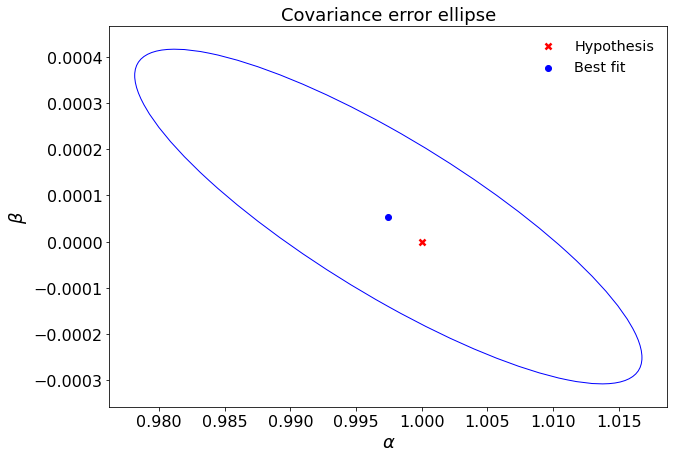

In [724]:
ideal_params = [1,0]
chi_2_ideal = compute_chi_2(digits,frequencies,stds,ideal_params,fit_func_lin)
delta_chi_2 = chi_2_ideal - chi_2_fit
p_value = chi2.sf(delta_chi_2,2)
print('\nDelta_chi_2 = {}\nCorresponding p-value = {}'
      .format(delta_chi_2,p_value))
err_ellipse(errs,params,cl=0.95)

We are now in the parameter space. That's because we are taking into account the variation of these to parameters in $\chi^2$. By comparing the values of the $\chi^2_{min}$ and the $\chi^2$ for the equiprobability hypothesis with the calculation of $\Delta\chi^2$, we are testing how compatible these two results are.This too is measured with the p-value, as before; however, now, the null hypothesis is that the equiprobability hypothesis and the linear fit are compatible. The large p-value obtained (higher than 0.9) is telling us that our result is even better than expected with the statistical fluctuations, and so that the null hypothesis can not be refused.

#### Conclusions
It's easy to see, both from the numerical values and the graphical representation, that the first 50000 digits of $\pi$ are in good agreement with the equiprobability hypothesis (nonetheless, we cannot take this as a proof that $\pi$ digits follow this behaviour, but rather that it is very likely). Furthermore, in the error ellipse, we can see that the equiprobability hypothesis lands in the inner part of it, backing up the hypothesis.

### Section 3 : Analyzing other notorious numbers
To make the procedure of further analyses (which will follow the same steps) smoother, all the previous functions will be put together in the 
sequence_analysis() function, that will be taking as input just the number's "name" and the associated sequence of digits

In [9]:
#Combining all the functions seen above
def sequence_analysis(number_name,digits_sequence,digits,fit_func) :
    '''
    This function conducts the complete analysis of the digits sequence of the number 
    of interest through the following steps:

    1)Computing the frequency of each digit and the associated error
      and printing them
    2)Computing the best linear fit parameters through the curve_fit() function,
      printing them and their correlation
    3)Computing the chi-square associated to those parameters and the one associated 
      to the equiprobability hypothesis (α=1,β=0), and printing them
    4)Computing and printing the delta_chi-square resulting from the difference 
      of the previous two
    5)Drawing the frequency histogram an the best fit
    6)Drawing the covariance error ellipse.

    Inputs:
        · number_name: string which will provide the histogram title.
        · digits_sequence: list of the number's digits.
    '''

    #1) Computing and printing frequencies and errors to obtain the fit parameters
    digit_frequencies = calculate_digit_frequencies(digits_sequence,digits)
    stds = calculate_stds(digit_frequencies,len(digits_sequence))
    print_freq_and_err(digit_frequencies,digits,stds)

    #2) Computing and printing the parameters
    params,errs = curve_fit(fit_func,digits,digit_frequencies,bounds=([-0.9,-0.9],[10,10]),absolute_sigma=True,sigma=stds)
    print_params_and_corr(params,errs)

    #3) Computing and printing the chi-squares
    chi_2_fit = compute_chi_2(digits,digit_frequencies,stds,params,fit_func)
    print_chi_2_and_p_value(chi_2_fit,digits,params)
    ideal_params = [1,0]
    chi_2_ideal = compute_chi_2(digits,digit_frequencies,stds,ideal_params,fit_func)
    print_chi_2_and_p_value(chi_2_ideal,digits,ideal_params)

    #4) Computing and printing the delta_chi-square
    delta_chi_2 = chi_2_ideal - chi_2_fit
    p_value = chi2.sf(delta_chi_2,2)
    print('\nDelta_chi_2 = {}\nCorresponding p-value = {}'
          .format(delta_chi_2,p_value))
          
    #5) Drawing the histogram and the fit
    draw_fit(digits,params,fit_func)
    draw_hyp(digits,ideal_params,fit_func)
    plot_histogram(number_name,digits,digit_frequencies, stds)

    #6) Drawing the ellipse
    err_ellipse(errs,params,cl=0.95)

Now we can use the sequence_analysis() function on other numbers
#### 1.6.1) The number e

0 frequency is 0.10038000000000939 ± 0.0013439036840488794
1 frequency is 0.10132000000000968 ± 0.0013494758804810682
2 frequency is 0.09664000000000825 ± 0.0013213683089888803
3 frequency is 0.09902000000000898 ± 0.001335777223941232
4 frequency is 0.10002000000000928 ± 0.0013417600351777318
5 frequency is 0.10156000000000975 ± 0.001350892789232423
6 frequency is 0.10018000000000933 ± 0.001342713428844796
7 frequency is 0.0994400000000091 ± 0.0013382950825584566
8 frequency is 0.10046000000000942 ± 0.001344379324446843
9 frequency is 0.10098000000000958 ± 0.0013474645791263504

Alpha value from fit = 0.9946692610635827 ± 0.007881556166210576
Beta value from fit = 0.00011503771817503068 ± 0.00014788729359598005
Correlation = -0.8427819067721299

Chi_2 value (with α = 0.9946692610635827, β = 0.00011503771817503068) = 9.607205429616487
Chi_2/ndof = 1.2009006787020609
Corresponding p-value = 0.29368378732609823

Chi_2 value (with α = 1, β = 0) = 10.213783909717197
Chi_2/ndof = 1.276722988

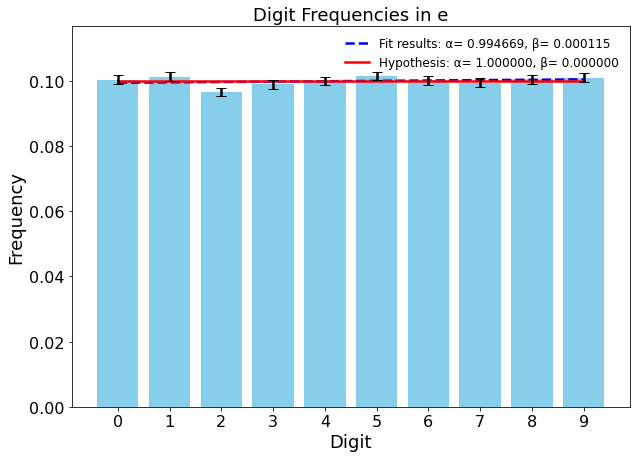

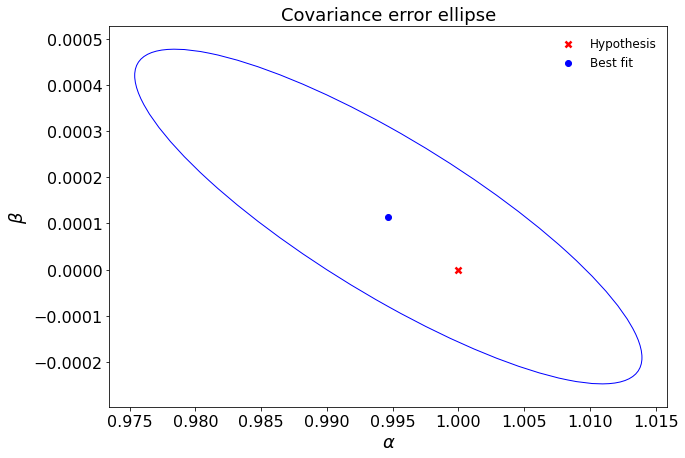

In [762]:
e_digits = generate_number_digits(N,mp.euler)
sequence_analysis('e',e_digits,digits,fit_func_lin)


#### 1.6.2) The square root of two √2

0 frequency is 0.09862000000000885 ± 0.0013333723830948885
1 frequency is 0.10128000000000967 ± 0.0013492395013488725
2 frequency is 0.09952000000000913 ± 0.0013387738390034914
3 frequency is 0.09954000000000914 ± 0.0013388934864283068
4 frequency is 0.10286000000001015 ± 0.0013585272938002244
5 frequency is 0.09938000000000909 ± 0.0013379358400163086
6 frequency is 0.09946000000000911 ± 0.0013384147966905276
7 frequency is 0.09980000000000921 ± 0.0013404473880015387
8 frequency is 0.0994200000000091 ± 0.0013381753517383833
9 frequency is 0.10012000000000931 ± 0.0013423560302692238

Alpha value from fit = 1.0003015070658567 ± 0.007879134117859227
Beta value from fit = -9.269321979390472e-06 ± 0.00014752257513401133
Correlation = -0.8426678376380576

Chi_2 value (with α = 1.0003015070658567, β = -9.269321979390472e-06) = 7.240644774919808
Chi_2/ndof = 0.905080596864976
Corresponding p-value = 0.5109056003801185

Chi_2 value (with α = 1, β = 0) = 7.245336235968863
Chi_2/ndof = 0.90566702

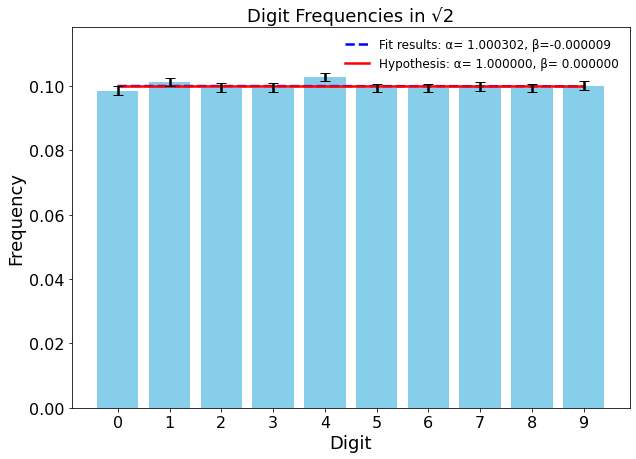

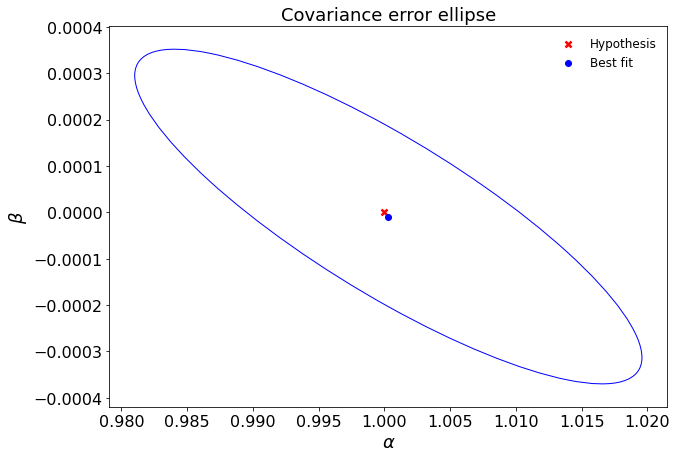

In [763]:
sqrt_2_digits = generate_number_digits(N,mp.sqrt(2))
sequence_analysis('√2',sqrt_2_digits,digits,fit_func_lin)

#### 1.6.3) The golden ratio ϕ

Alpha value from fit = 1.0015251934558704 ± 0.007893032188875682
Beta value from fit = -3.491111881911593e-05 ± 0.00014782485757182606
Correlation = -0.8432608872027239

Chi_2 value (with α = 1.0015251934558704, β = -3.491111881911593e-05) = 2.86458489817421
Chi_2/ndof = 0.35807311227177624
Corresponding p-value = 0.9425658514122597

Chi_2 value (with α = 1, β = 0) = 2.920480149323883
Chi_2/ndof = 0.3650600186654854
Corresponding p-value = 0.9392482132675788

Delta_chi_2 = 0.055895251149673086
Corresponding p-value = 0.9724392964166868


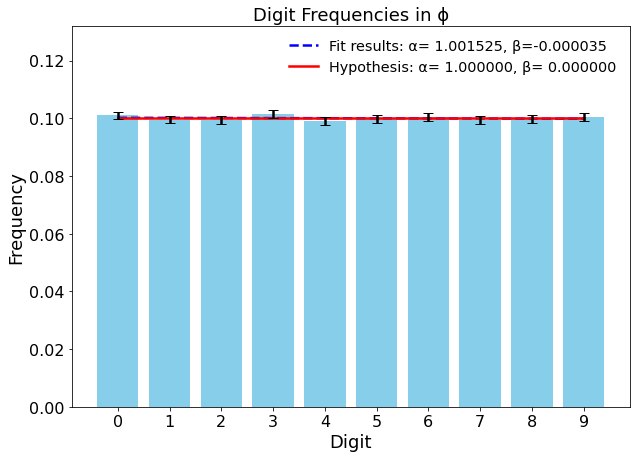

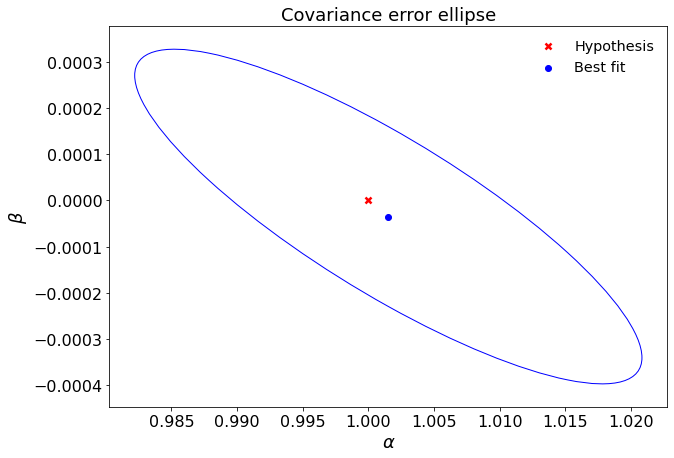

In [728]:
golden_ratio_digits = generate_number_digits(N,mp.phi)
sequence_analysis('ϕ',golden_ratio_digits,digits,fit_func_lin)

#### 1.6.4) The Fibonacci series

Alpha value from fit = 1.001672834481394 ± 0.007903855857034327
Beta value from fit = -4.0433853114065594e-05 ± 0.00014810055083798828
Correlation = -0.8437471264497906

Chi_2 value (with α = 1.001672834481394, β = -4.0433853114065594e-05) = 9.15971832551735
Chi_2/ndof = 1.1449647906896687
Corresponding p-value = 0.32900209997548596

Chi_2 value (with α = 1, β = 0) = 9.235471139655692
Chi_2/ndof = 1.1544338924569615
Corresponding p-value = 0.3228231101163137

Delta_chi_2 = 0.07575281413834212
Corresponding p-value = 0.9628319327582365


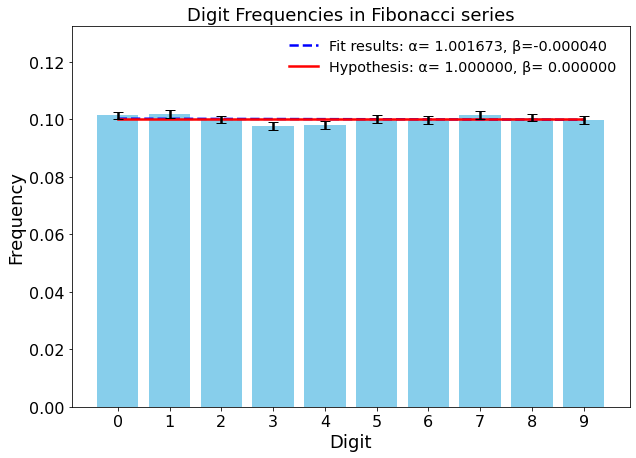

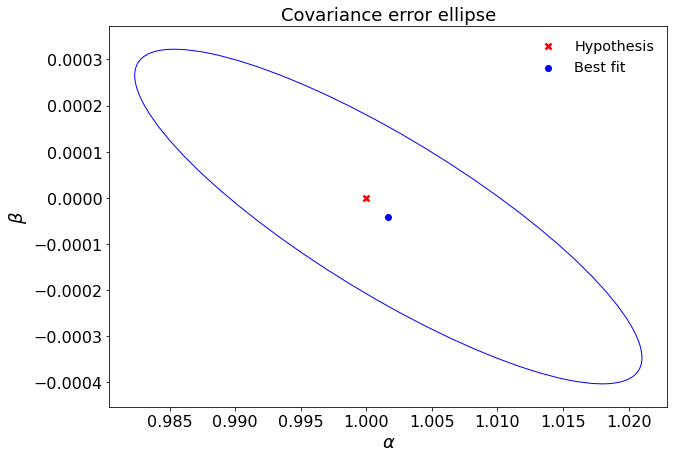

In [729]:
sequence_analysis('Fibonacci numbers concatenation',fib_digits(N),digits,fit_func_lin)

#### 1.6.5) The Lucas sequence

0 frequency is 0.09882000000000891 ± 0.0013345756449149456
1 frequency is 0.10370000000001041 ± 0.0013634244386837742
2 frequency is 0.10316000000001024 ± 0.0013602794889287138
3 frequency is 0.10054000000000944 ± 0.001344854701445532
4 frequency is 0.10296000000001018 ± 0.0013591117569943106
5 frequency is 0.09672000000000827 ± 0.0013218565852618556
6 frequency is 0.0984600000000088 ± 0.0013324085589638567
7 frequency is 0.10064000000000947 ± 0.0013454485527139828
8 frequency is 0.09708000000000838 ± 0.0013240504038744653
9 frequency is 0.09792000000000864 ± 0.0013291476486832225

Alpha value from fit = 1.0211213047716425 ± 0.007917080447158106
Beta value from fit = -0.0004775237499052423 ± 0.00014740574015236637
Correlation = -0.8443835644917508

Chi_2 value (with α = 1.0211213047716425, β = -0.0004775237499052423) = 22.968675494240205
Chi_2/ndof = 2.8710844367800257
Corresponding p-value = 0.003404696968013057

Chi_2 value (with α = 1, β = 0) = 33.47907437450648
Chi_2/ndof = 4.18488

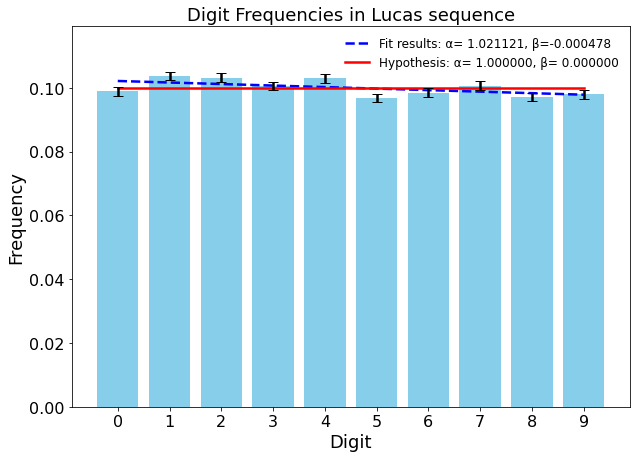

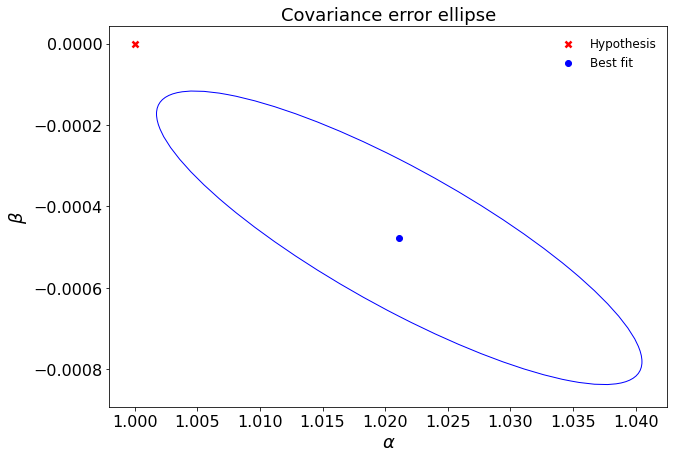

In [764]:
sequence_analysis('Lucas sequence',luc_digits(N),digits,fit_func_lin)

#### 1.6.6) The Padovan sequence

0 frequency is 0.09674000000000828 ± 0.0013219786110221805
1 frequency is 0.10618000000001117 ± 0.0013777213622500654
2 frequency is 0.10100000000000958 ± 0.0013475830215612518
3 frequency is 0.09936000000000908 ± 0.001337816059105341
4 frequency is 0.10114000000000962 ± 0.0013484116611777552
5 frequency is 0.10058000000000945 ± 0.0013450922912574257
6 frequency is 0.10070000000000949 ± 0.0013458046663614122
7 frequency is 0.10020000000000934 ± 0.0013428325286498496
8 frequency is 0.0981200000000087 ± 0.0013303568363413404
9 frequency is 0.09598000000000804 ± 0.0013173294166608936

Alpha value from fit = 1.016254342607335 ± 0.00789000100440087
Beta value from fit = -0.00037292741959722226 ± 0.00014694748848563112
Correlation = -0.8432306686088862

Chi_2 value (with α = 1.016254342607335, β = -0.00037292741959722226) = 33.02212377945901
Chi_2/ndof = 4.127765472432376
Corresponding p-value = 6.1025533458194664e-05

Chi_2 value (with α = 1, β = 0) = 39.48476169868011
Chi_2/ndof = 4.935595

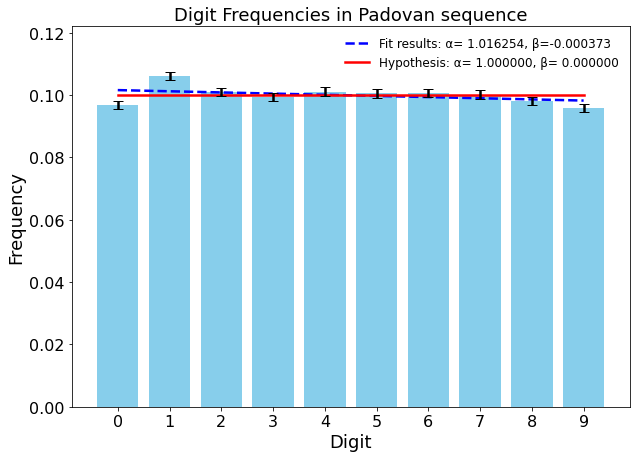

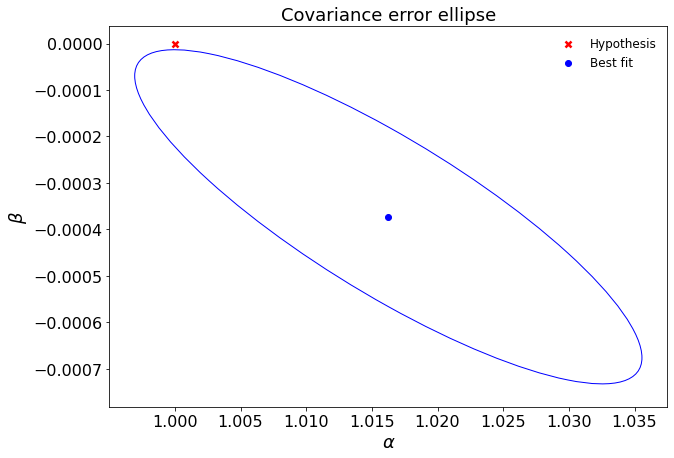

In [765]:
sequence_analysis('Padovan sequence',pad_digits(N),digits,fit_func_lin)

Following the exact same reasoning adopted for $\pi$, we can conclude that e, $\sqrt2$, $\phi$ and the Fibonacci numbers concatenation are all consistent with the equiprobability hypothesis, if we consider their first 50000 digits, with p-values really close to 1.
$\newline$
Meanwhile, if we look at the Lucas and the Padovan sequences, the discrepancy between the considered sample and the hypothesis is pretty noticeable, suggesting a rejection of the latter; a deeper analysis of the p-value behavior based on the number of digits consider might provide a better understang if this conclusion is accurate or not.

## II - The law of anomalous numbers.
he first (non-zero) numerical digit of any random numbers you meet in everyday life (reading newspaper, sport results, measurements, ...) are not equally distributed. The digit d = 1 is over-represented
as first-digit, with a frequency exceeding 30%, while the rate of poor digit d = 9 is below 5%, far from
the equiprobability hypothesis fd = 1/9. The first-digit frequency is well described by the discrete
Newcomb-Benford probability mass function (base-10):
f
B
d = log10(d + 1) − log10(d) (d ∈ [1, 9]) ; X
9
d=1
f
B
d = log10(10) − log10(1) = 1
In particular, the 1st-digit of the Fibonacci numbers, Fn closely follow this frequency distribution.
### 2.1) Checking the Newcomb-Benford p.m.f. for the first digit of the Fibonacci numbers
Let's consider if the Newcomb-Benford probability is applicable if we consider the first 50000 Fibonacci numbers

50000 digits were used.
1 frequency is 0.3010400000000195 ± 0.002051413748613418
2 frequency is 0.17607999999999713 ± 0.0017033838886169974
3 frequency is 0.12496000000001692 ± 0.0014788170840236644
4 frequency is 0.09688000000000832 ± 0.0013228323068326289
5 frequency is 0.0791800000000029 ± 0.0012075638914774028
6 frequency is 0.06697999999999917 ± 0.0011179774559444326
7 frequency is 0.05795999999999798 ± 0.0010449941473520147
8 frequency is 0.051159999999998255 ± 0.000985318774813496
9 frequency is 0.045759999999998476 ± 0.0009345161571636802

Alpha value from fit = 0.9999084995726725 ± 0.02166610898471322
Beta value from fit = -6.2412040312999e-05 ± 0.014341965601774313
Correlation = 0.9743471604804956

Chi_2 value (with α = 0.9999084995726725, β = -6.2412040312999e-05) = 0.0026529559254220513
Chi_2/ndof = 0.0003789937036317216
Corresponding p-value = 0.9999999999926994

Chi_2 value (with α = 1, β = 0) = 0.00267189706960606
Chi_2/ndof = 0.00038169958137229427
Corresponding p-value

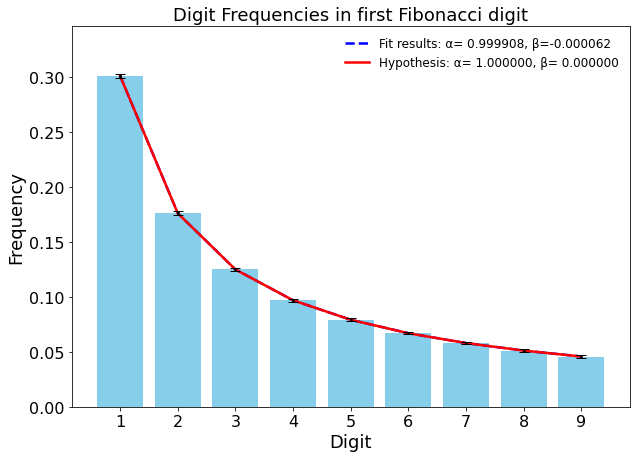

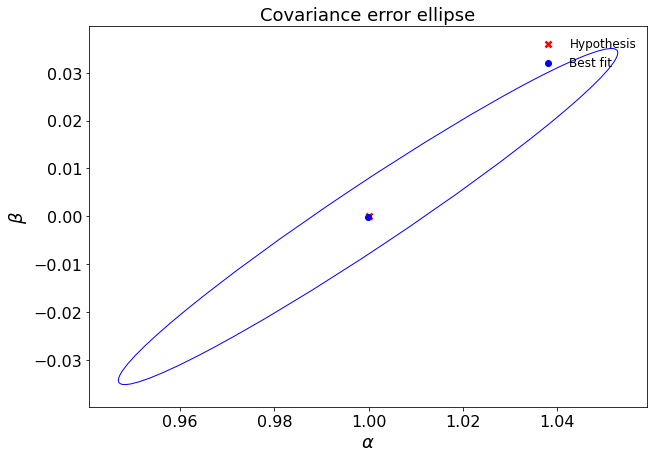

In [34]:
sys.set_int_max_str_digits(0)

N=5*10**4
fibfirstdig = '11'
fibi,fibj = 1,1

while len(fibfirstdig) < N:
    fibk = fibi + fibj
    fibi, fibj = fibj, fibk
    fibfirstdig += str(fibk)[0]

fibfirstdig = fibfirstdig[0:N]
fib_first_digit = [int(digit) for digit in fibfirstdig if digit.isdigit()]

print(f'{len(fibfirstdig)} digits were used.')

dig_1_to_9 = np.linspace(1,9,9)

def fit_func_log(d,alpha,beta):
    return np.log10(d+alpha) - np.log10(d+beta)
    
sequence_analysis('first Fibonacci digit',fib_first_digit,dig_1_to_9,fit_func_log)


It's crystal clear that the Newcomb-Benford probability hypothesis is consistent with the sample we took in consideration, with a graphical representation that overlaps almost perfectly and a p-value barely differing from 1 (if not for a factor $10^5$).
### 2.2) Checking the Newcomb-Benford probability for the multiplication of randomly independent variables 
In order to check the adherence of the hypothesis to this number, we are gonna consider the following cases:
$\newline$
N = 50
$\newline$
N = 100
$\newline$
N = 500
$\newline$
N = 1000
#### 2.2.1) N = 50

1 frequency is 0.2663199999999848 ± 0.001976834123541947
2 frequency is 0.1638000000000019 ± 0.0016551106307434633
3 frequency is 0.13320000000001375 ± 0.0015195904711468157
4 frequency is 0.1105200000000125 ± 0.0014021792296280082
5 frequency is 0.08908000000000593 ± 0.0012739289901717826
6 frequency is 0.07580000000000187 ± 0.0011836752933131753
7 frequency is 0.063179999999998 ± 0.0010880099962775917
8 frequency is 0.053879999999998145 ± 0.0010097221954577242
9 frequency is 0.04421999999999854 ± 0.0009193975375211603

Alpha value from fit = 1.550267316038876 ± 0.030917264688474846
Beta value from fit = 0.385006504048118 ± 0.021465308644606586
Correlation = 0.9831053298143027

Chi_2 value (with α = 1.550267316038876, β = 0.385006504048118) = 148.35321863885363
Chi_2/ndof = 21.193316948407663
Corresponding p-value = 9.000843449242272e-29

Chi_2 value (with α = 1, β = 0) = 636.3630207135644
Chi_2/ndof = 90.90900295908064
Corresponding p-value = 3.581392459828278e-133

Delta_chi_2 = 488

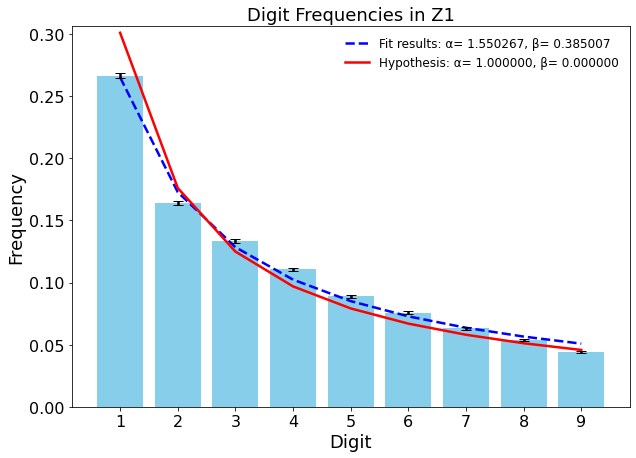

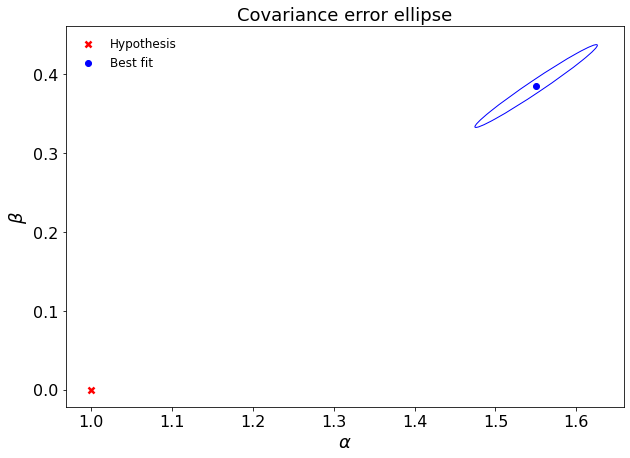

In [847]:
N = 50
Z1 = Var_Z1(N)
sequence_analysis('Z1',Z1,dig_1_to_9,fit_func_log)

It's clear that the Benford distribution is not consistent with the sample.
#### 2.2.2) N = 100

1 frequency is 0.3036200000000221 ± 0.002056379807331363
2 frequency is 0.17571999999999727 ± 0.0017020134053526033
3 frequency is 0.12916000000001532 ± 0.001499851288628385
4 frequency is 0.09688000000000832 ± 0.0013228323068326289
5 frequency is 0.0775600000000024 ± 0.00119619769603525
6 frequency is 0.06715999999999922 ± 0.0011193706660440885
7 frequency is 0.05619999999999805 ± 0.0010299666014002423
8 frequency is 0.04955999999999832 ± 0.0009706060622106014
9 frequency is 0.04413999999999854 ± 0.0009186039451254134

Alpha value from fit = 0.9558967998301291 ± 0.020937955113826387
Beta value from fit = -0.02978212776943701 ± 0.01379332645745988
Correlation = 0.9732690249561736

Chi_2 value (with α = 0.9558967998301291, β = -0.02978212776943701) = 15.712779954097016
Chi_2/ndof = 2.244682850585288
Corresponding p-value = 0.027873972341314897

Chi_2 value (with α = 1, β = 0) = 20.248259521297104
Chi_2/ndof = 2.8926085030424433
Corresponding p-value = 0.005057684415725099

Delta_chi_2 =

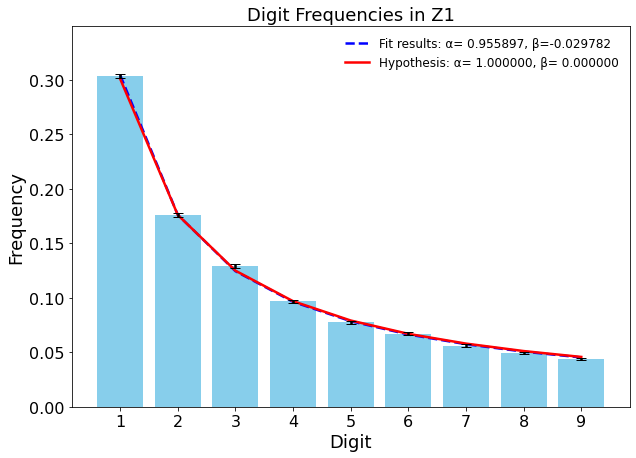

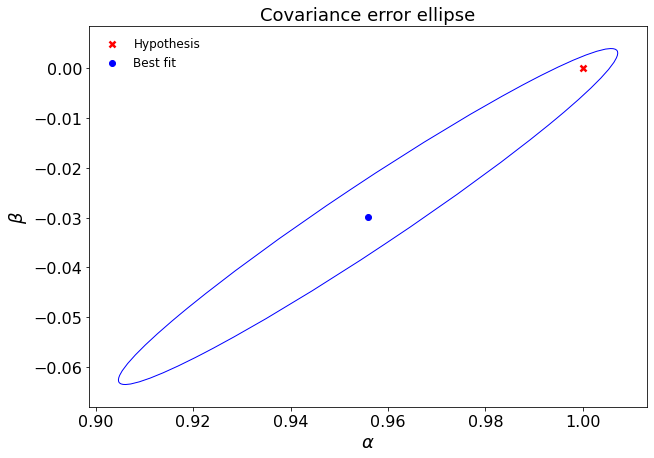

In [11]:
N = 100
Z1 = Var_Z1(N)
sequence_analysis('Z1',Z1,dig_1_to_9,fit_func_log)

We can see that the the fit begins to match the hypothesis, but the result is not conclusive yet.
#### 2.2.3) N = 500

1 frequency is 0.29998000000001845 ± 0.002049351114865422
2 frequency is 0.17309999999999828 ± 0.001691959751294332
3 frequency is 0.1258800000000166 ± 0.0014834704284212234
4 frequency is 0.09798000000000866 ± 0.0013295105836360007
5 frequency is 0.0788400000000028 ± 0.0012051908927634854
6 frequency is 0.06617999999999892 ± 0.001111757236090677
7 frequency is 0.060979999999997855 ± 0.0010701536300924098
8 frequency is 0.051139999999998256 ± 0.0009851365428203182
9 frequency is 0.04591999999999847 ± 0.0009360700144753982

Alpha value from fit = 1.0256005986255394 ± 0.02210348340933909
Beta value from fit = 0.017604508673536926 ± 0.014673228322708579
Correlation = 0.9749718257427662

Chi_2 value (with α = 1.0256005986255394, β = 0.017604508673536926) = 11.355661406081055
Chi_2/ndof = 1.622237343725865
Corresponding p-value = 0.123840082934502

Chi_2 value (with α = 1, β = 0) = 12.820757126851559
Chi_2/ndof = 1.8315367324073655
Corresponding p-value = 0.076597921295579

Delta_chi_2 = 1.

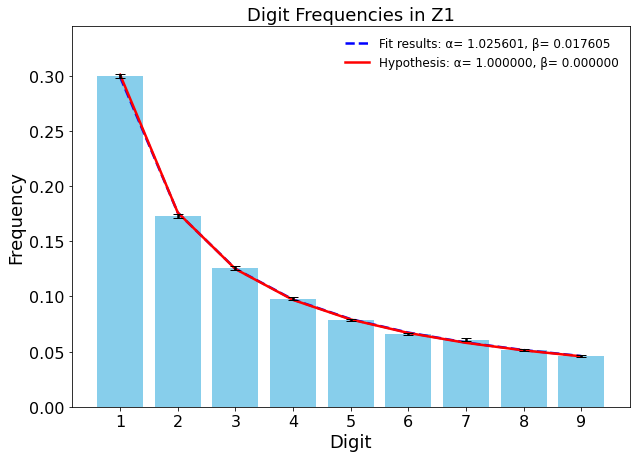

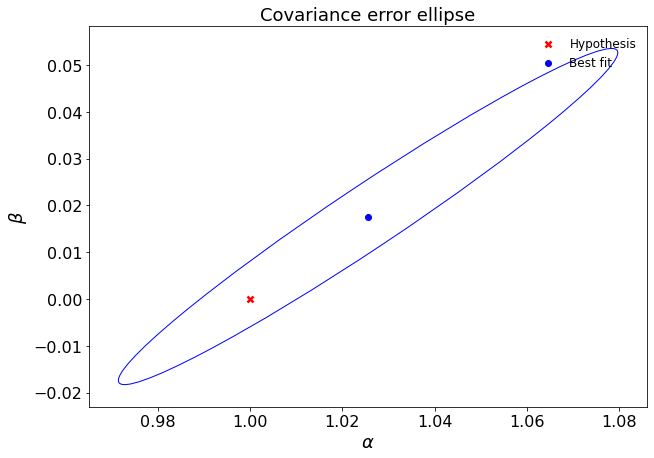

In [12]:
N = 500
Z1 = Var_Z1(N)
sequence_analysis('Z1',Z1,dig_1_to_9,fit_func_log)

Already from this instance, it would be pretty safe to assume that the hypothesis is consistent with the sample, showing what would look like an asymptotic behaviour.
#### 2.2.4) N = 1000

1 frequency is 0.3030000000000215 ± 0.002055193421554324
2 frequency is 0.1735999999999981 ± 0.0016938892525782125
3 frequency is 0.12268000000001622 ± 0.0014671715482520253
4 frequency is 0.09710000000000839 ± 0.0013241721187217828
5 frequency is 0.08030000000000324 ± 0.0012153346041317405
6 frequency is 0.06843999999999961 ± 0.0011292118171538914
7 frequency is 0.058279999999997965 ± 0.0010476969180063308
8 frequency is 0.0500399999999983 ± 0.0009750487003221785
9 frequency is 0.04655999999999844 ± 0.0009422543860338204

Alpha value from fit = 0.9915287567630305 ± 0.021580696173970054
Beta value from fit = -0.005680626309156586 ± 0.014270232168927673
Correlation = 0.974274579968977

Chi_2 value (with α = 0.9915287567630305, β = -0.005680626309156586) = 10.015249529247468
Chi_2/ndof = 1.4307499327496382
Corresponding p-value = 0.18771093628265487

Chi_2 value (with α = 1, β = 0) = 10.171385228822794
Chi_2/ndof = 1.4530550326889706
Corresponding p-value = 0.17906748716579468

Delta_chi

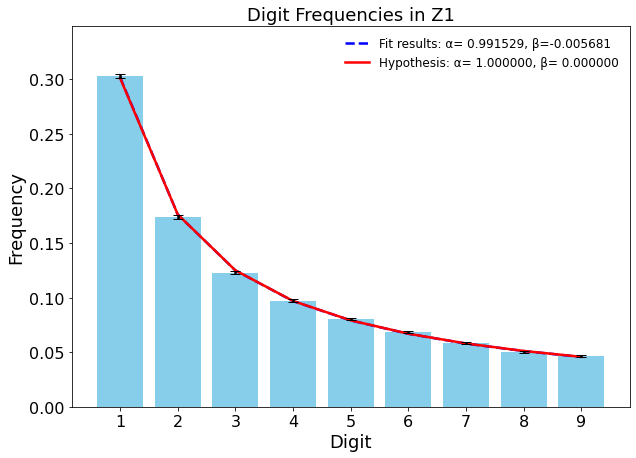

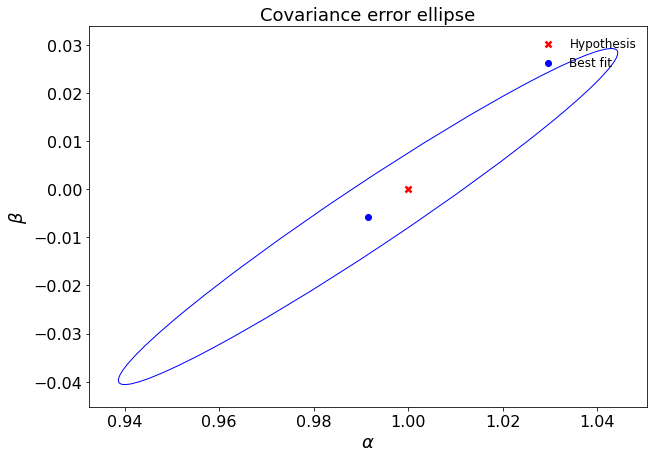

In [19]:
N = 1000
Z1 = Var_Z1(N)
sequence_analysis('Z1',Z1,dig_1_to_9,fit_func_log)

With a sample this size, the high frequency of generations of the number Z1 that show a p-value that would be considered acceptable strongly suggest that the multiplication of a large number of independent random variables does indeed  follow the Benford law asymptotically.
### Checking the Newcomb-Benford probability for $\Z = (X/Y)^n$  where both X and Y are uniformly distributed
In order to verify if the this number does asymptotically follow the Benford distribution, we are gonna consider the following cases:
$\newline$
N = 4
$\newline$
N = 5
$\newline$
N = 6
$\newline$
N = 10
#### 2.3.1) N = 4

1 frequency is 0.19285999999999062 ± 0.0017644547055676676
2 frequency is 0.20561999999998568 ± 0.001807431412806536
3 frequency is 0.18371999999999417 ± 0.0017318600497730544
4 frequency is 0.13264000000001397 ± 0.0015168825294004163
5 frequency is 0.09986000000000923 ± 0.0013408055817306802
6 frequency is 0.06967999999999999 ± 0.001138636883295109
7 frequency is 0.05035999999999829 ± 0.0009779966298510282
8 frequency is 0.03681999999999884 ± 0.0008421910424600694
9 frequency is 0.028439999999999178 ± 0.0007433863921272601

Alpha value from fit = 1.8879712439633578 ± 0.036393054254675525
Beta value from fit = 0.6995963356869234 ± 0.02650856652302044
Correlation = 0.9867697561810984

Chi_2 value (with α = 1.8879712439633578, β = 0.6995963356869234) = 4645.417919282462
Chi_2/ndof = 663.631131326066
Corresponding p-value = 0.0

Chi_2 value (with α = 1, β = 0) = 6868.862369372913
Chi_2/ndof = 981.266052767559
Corresponding p-value = 0.0

Delta_chi_2 = 2223.444450090451
Corresponding p-val

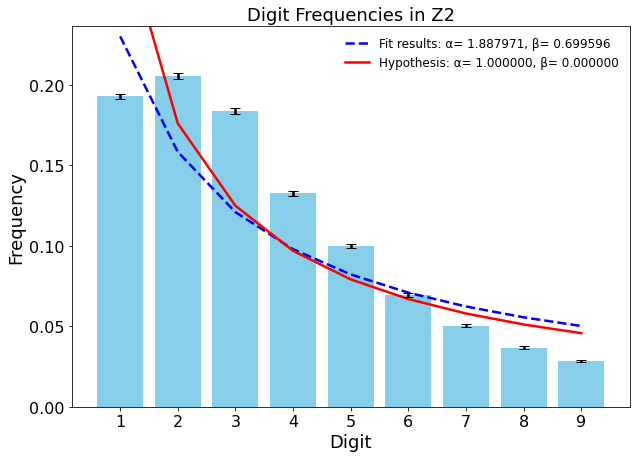

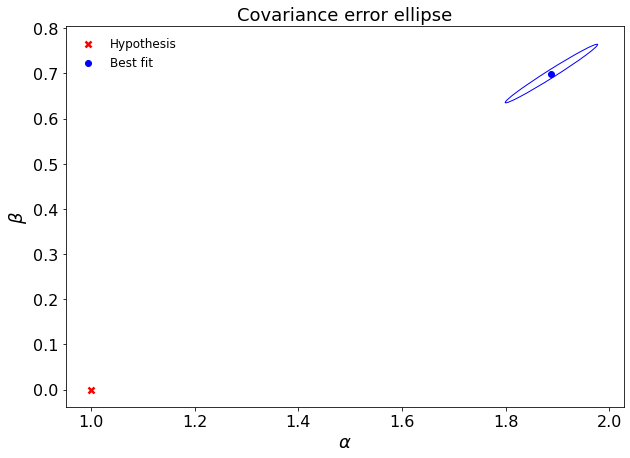

In [798]:
N = 4
Z2 = Var_Z2(N)
sequence_analysis('Z2',Z2,dig_1_to_9,fit_func_log)

This case is completely inconsistent with the hypothesis.
#### 2.3.2) N = 5

1 frequency is 0.27057999999998905 ± 0.00198678868327759
2 frequency is 0.16704000000000063 ± 0.001668158496066848
3 frequency is 0.1302600000000149 ± 0.0015052729480065136
4 frequency is 0.11580000000001411 ± 0.0014310161424666797
5 frequency is 0.08992000000000619 ± 0.0012793310251846867
6 frequency is 0.07390000000000128 ± 0.0011699469218729634
7 frequency is 0.06181999999999782 ± 0.001077017062074674
8 frequency is 0.04953999999999832 ± 0.0009704204078645346
9 frequency is 0.041139999999998664 ± 0.0008882285786890531

Alpha value from fit = 1.4198896925043396 ± 0.02856438555889609
Beta value from fit = 0.29523841379021504 ± 0.019686132310283416
Correlation = 0.9814827937514046

Chi_2 value (with α = 1.4198896925043396, β = 0.29523841379021504) = 277.844519082194
Chi_2/ndof = 39.69207415459914
Corresponding p-value = 3.236024288613371e-56

Chi_2 value (with α = 1, β = 0) = 599.2817450249056
Chi_2/ndof = 85.6116778607008
Corresponding p-value = 3.476765374361736e-125

Delta_chi_2 = 3

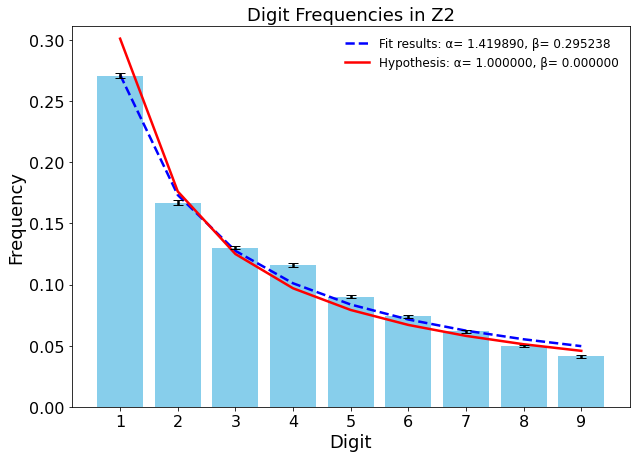

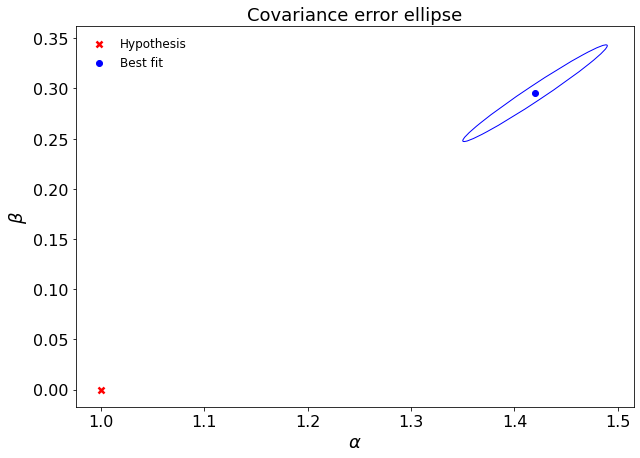

In [799]:
N = 5
Z2 = Var_Z2(N)
sequence_analysis('Z2',Z2,dig_1_to_9,fit_func_log)

Same goes for this one as the on before.
#### 2.3.3) N = 6

1 frequency is 0.2959000000000144 ± 0.002041289739356008
2 frequency is 0.17583999999999722 ± 0.0017024705248549722
3 frequency is 0.12926000000001528 ± 0.0015003456428437504
4 frequency is 0.1020200000000099 ± 0.001353602006499753
5 frequency is 0.0834200000000042 ± 0.00123661718894736
6 frequency is 0.06669999999999908 ± 0.0011158056282345881
7 frequency is 0.056099999999998054 ± 0.0010291043678849904
8 frequency is 0.04883999999999835 ± 0.0009638947494410218
9 frequency is 0.04191999999999863 ± 0.0008962445380586567

Alpha value from fit = 1.0360830227457491 ± 0.02215245622713061
Beta value from fit = 0.025623309188289537 ± 0.014737256194294555
Correlation = 0.9749569044298664

Chi_2 value (with α = 1.0360830227457491, β = 0.025623309188289537) = 64.86125333445067
Chi_2/ndof = 9.265893333492953
Corresponding p-value = 1.603533424796874e-11

Chi_2 value (with α = 1, β = 0) = 68.1515077479736
Chi_2/ndof = 9.735929678281943
Corresponding p-value = 3.488968113078093e-12

Delta_chi_2 = 3

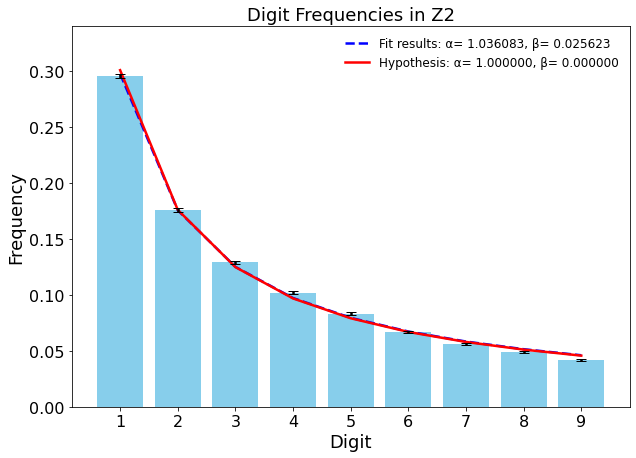

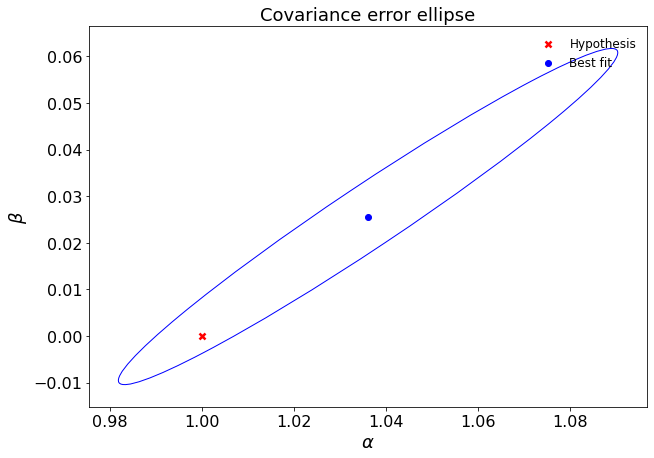

In [21]:
N = 6
Z2 = Var_Z2(N)
sequence_analysis('Z2',Z2,dig_1_to_9,fit_func_log)

Here we start observing a promising behaviour, but it's not consistent enough to validate our hypothesis
#### 2.3.4) N = 10

1 frequency is 0.2991200000000176 ± 0.002047668066850714
2 frequency is 0.18067999999999534 ± 0.001720666949761034
3 frequency is 0.12732000000001603 ± 0.0014907019661891637
4 frequency is 0.09950000000000912 ± 0.0013386541749085706
5 frequency is 0.07932000000000294 ± 0.001208539098250466
6 frequency is 0.0651199999999986 ± 0.0011034435699209886
7 frequency is 0.05617999999999805 ± 0.0010297942279892452
8 frequency is 0.048739999999998354 ± 0.0009629580717767364
9 frequency is 0.044019999999998546 ± 0.0009174120077696681

Alpha value from fit = 0.9868467101174805 ± 0.021364981522753484
Beta value from fit = -0.008514236076576665 ± 0.014131212346735714
Correlation = 0.9738466055662018

Chi_2 value (with α = 0.9868467101174805, β = -0.008514236076576665) = 29.60567091326127
Chi_2/ndof = 4.229381559037324
Corresponding p-value = 0.00011214661378525262

Chi_2 value (with α = 1, β = 0) = 29.99055920687345
Chi_2/ndof = 4.284365600981921
Corresponding p-value = 9.533909915020464e-05

Delta_c

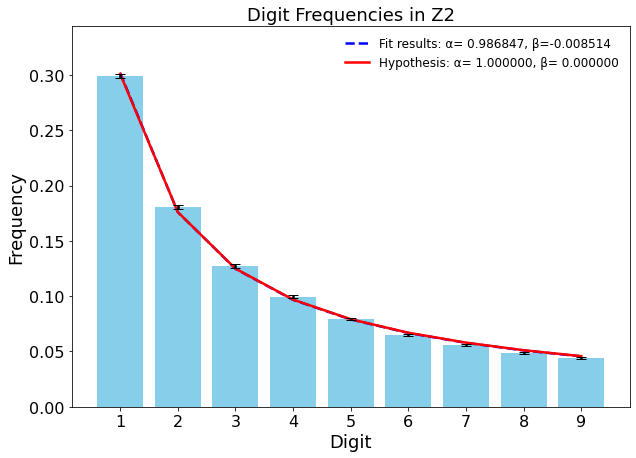

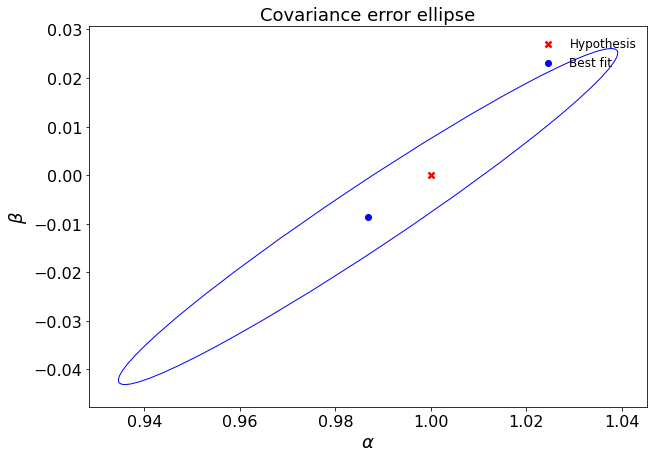

In [32]:
N = 10
Z2 = Var_Z2(N)
sequence_analysis('Z2',Z2,dig_1_to_9,fit_func_log)

Here the legitimacy of the hypothesis is pretty clear, with a p-value that is consistently high with each generation, often times being close to 1